# CSE422 Lab Project — Disease Classification
### BRAC University | Machine Learning Lab

**Dataset:** `disease_classification_dataset.csv` — 1800 rows, 8 features, 3 classes (Type A / B / C)

**Models used:**
- Neural Network (MLP) — *mandatory*
- Decision Tree — *model 2*
- KNN — *model 3*
- K-Means Clustering — *unsupervised (mandatory)*


---
## Step 0: Install & Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split

# Sklearn — supervised models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Sklearn — unsupervised
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)


---
## 📖 Section 1: Introduction

This project aims to build machine learning models that **predict a patient's disease type**
based on clinical and demographic features.

**Problem:** Multi-class classification — predict one of three disease types: *Type A, Type B, Type C*.

**Input features:** Age, BMI, Blood Pressure, Cholesterol, Heart Rate, Smoking Habit, Physical Activity Level, Family History.

**Motivation:** Early and automated disease classification can assist clinicians in diagnosis,
reduce human error, and enable faster treatment decisions using patient data.

**Approach:** We apply supervised learning (Neural Network, Decision Tree, KNN) and
unsupervised learning (K-Means) and compare their performance using standard evaluation metrics.

---
## 📊 Section 2: Dataset Description

### 2.1 Load & Basic Info

In [28]:
df = pd.read_csv('/content/sample_data/disease_classification_dataset.csv')

print('=' * 50)
print('DATASET SHAPE')
print('=' * 50)
print(f'  Rows (data points) : {df.shape[0]}')
print(f'  Columns (features) : {df.shape[1] - 1} input + 1 output = {df.shape[1]} total')

print('\n' + '=' * 50)
print('FEATURE TYPES')
print('=' * 50)
quant = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Heart_Rate']
categ = ['Smoking_Habit', 'Physical_Activity_Level', 'Family_History']
print(f'  Quantitative: {quant}')
print(f'  Categorical : {categ}')
print(f'  Output label: Disease_Type')

print('\n' + '=' * 50)
print('PROBLEM TYPE')
print('=' * 50)
print('  → CLASSIFICATION')
print('  Reason: Output (Disease_Type) contains discrete class labels')
print('  (Type A, Type B, Type C), not continuous numeric values.')

print('\n' + '=' * 50)
print('ENCODING NEEDED?')
print('=' * 50)
print('  → YES. ML algorithms require numeric inputs.')
print('  Categorical features must be converted via Label Encoding.')

DATASET SHAPE
  Rows (data points) : 1800
  Columns (features) : 8 input + 1 output = 9 total

FEATURE TYPES
  Quantitative: ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Heart_Rate']
  Categorical : ['Smoking_Habit', 'Physical_Activity_Level', 'Family_History']
  Output label: Disease_Type

PROBLEM TYPE
  → CLASSIFICATION
  Reason: Output (Disease_Type) contains discrete class labels
  (Type A, Type B, Type C), not continuous numeric values.

ENCODING NEEDED?
  → YES. ML algorithms require numeric inputs.
  Categorical features must be converted via Label Encoding.


In [29]:
print('First 5 rows:')
df.head()

First 5 rows:


,Age,BMI,Blood_Pressure,Cholesterol,Heart_Rate,Smoking_Habit,Physical_Activity_Level,Family_History,Disease_Type
0,51,29.317228,155,285.0,104,Non-Smoker,High,No,Type B
1,25,32.918835,117,150.0,85,Non-Smoker,Low,No,Type C
2,41,23.079369,140,208.0,118,Non-Smoker,Low,No,Type C
3,30,37.053188,128,184.0,65,Smoker,Moderate,Yes,Type C
4,68,29.756353,102,165.0,102,Smoker,Low,Yes,Type A


In [30]:
print('Data types & missing values:')
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

Data types & missing values:
                           dtype  missing  missing%
Age                        int64        0       0.0
BMI                      float64       90       5.0
Blood_Pressure             int64        0       0.0
Cholesterol              float64       90       5.0
Heart_Rate                 int64        0       0.0
Smoking_Habit             object       90       5.0
Physical_Activity_Level   object        0       0.0
Family_History            object        0       0.0
Disease_Type              object        0       0.0


### 2.2 Correlation Heatmap

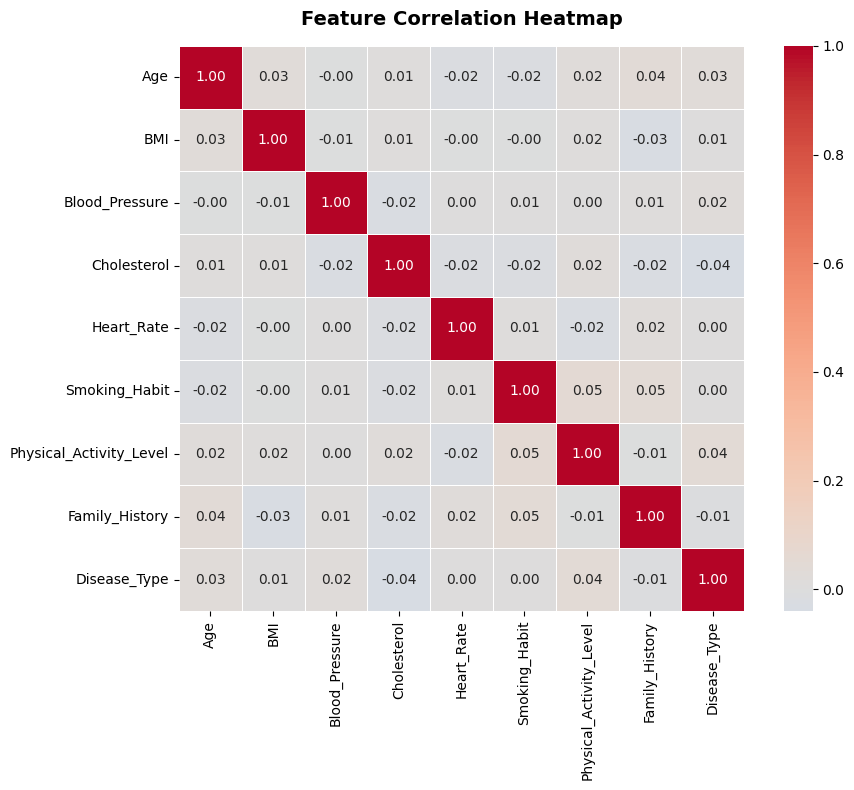


Correlation with target (Disease_Type_enc):
Physical_Activity_Level    0.042005
Cholesterol               -0.039759
Age                        0.031461
Blood_Pressure             0.018971
Family_History            -0.011137
BMI                        0.006459
Heart_Rate                 0.002866
Smoking_Habit              0.001107
Name: Disease_Type, dtype: float64

 Interpretation:
All feature-target correlations are < 0.05 (near zero).
No individual feature has a strong linear relationship with Disease_Type.
This suggests the dataset may be synthetically generated.


In [31]:
# Temporarily encode all columns for correlation
df_enc = df.copy()
le_temp = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le_temp.fit_transform(df_enc[col].astype(str))

plt.figure(figsize=(10, 8))
corr = df_enc.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with target (Disease_Type_enc):')
print(corr['Disease_Type'].drop('Disease_Type').sort_values(key=abs, ascending=False))

print('\n Interpretation:')
print('All feature-target correlations are < 0.05 (near zero).')
print('No individual feature has a strong linear relationship with Disease_Type.')
print('This suggests the dataset may be synthetically generated.')

### 2.3 Imbalanced Dataset Check

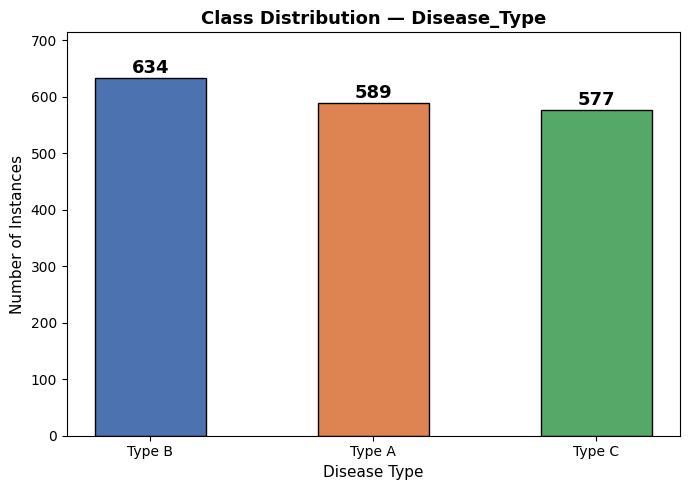

Disease_Type
Type B    634
Type A    589
Type C    577
Name: count, dtype: int64

 Conclusion: Classes are nearly balanced (589 / 634 / 577).
No oversampling (SMOTE) or undersampling is required.
Stratified split will be used to maintain proportions.


In [32]:
class_counts = df['Disease_Type'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(class_counts.index, class_counts.values,
               color=['#4C72B0', '#DD8452', '#55A868'],
               edgecolor='black', width=0.5)
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 8,
             str(val), ha='center', fontweight='bold', fontsize=13)
plt.title('Class Distribution — Disease_Type', fontsize=13, fontweight='bold')
plt.xlabel('Disease Type', fontsize=11)
plt.ylabel('Number of Instances', fontsize=11)
plt.ylim(0, class_counts.max() + 80)
plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(class_counts)
print('\n Conclusion: Classes are nearly balanced (589 / 634 / 577).')
print('No oversampling (SMOTE) or undersampling is required.')
print('Stratified split will be used to maintain proportions.')

### 2.4 Exploratory Data Analysis (EDA)

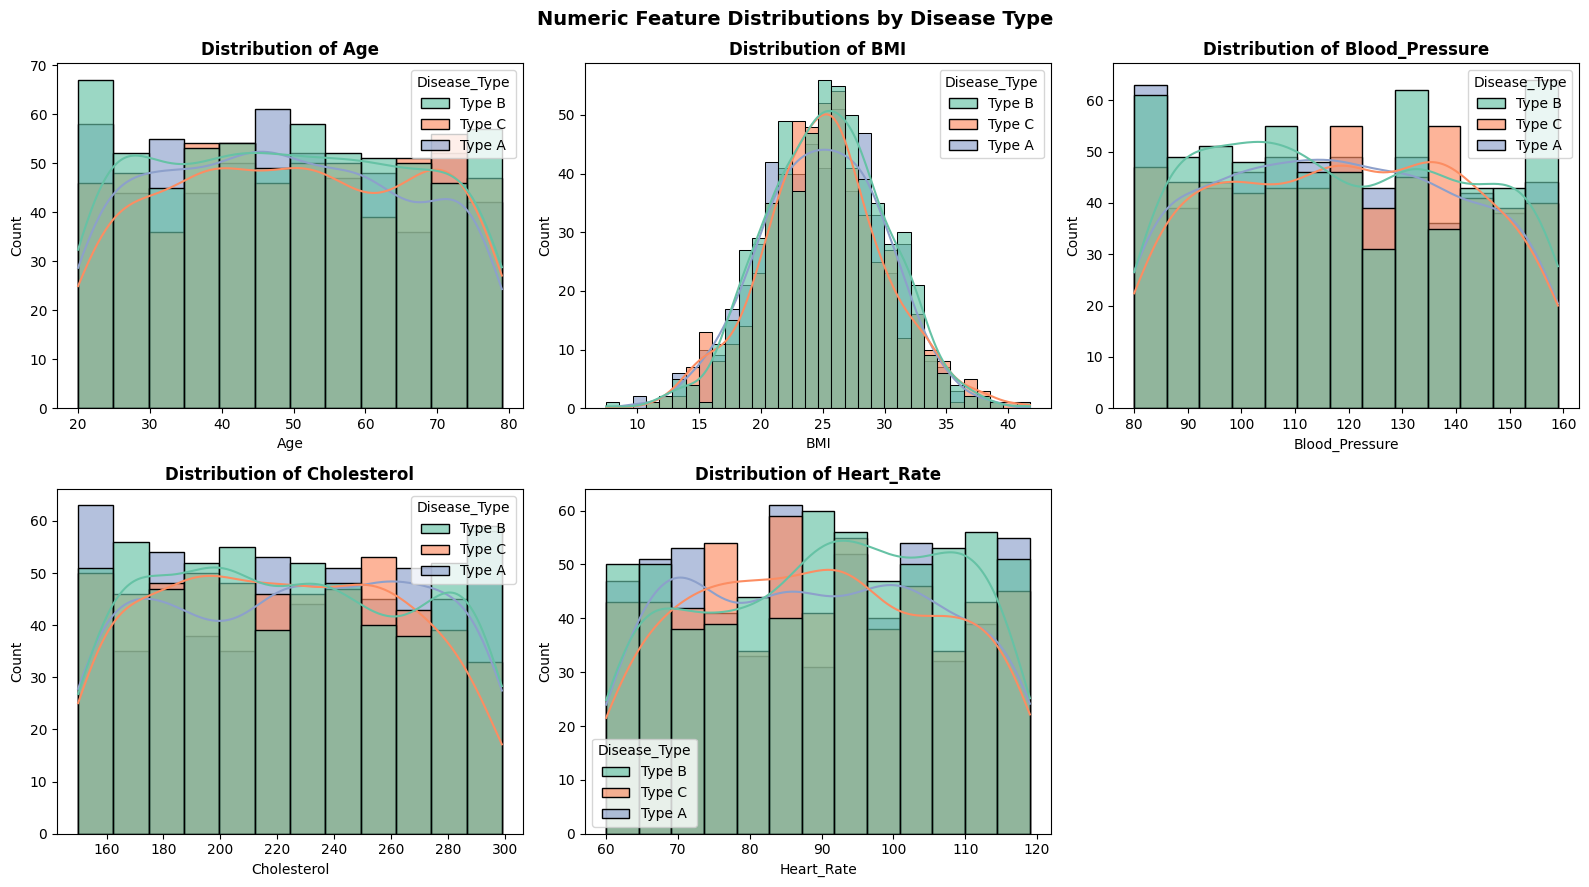

Observation: Distributions of all numeric features heavily overlap
across all 3 disease types → low discriminative power.


In [33]:
# --- EDA Plot 1: Numeric feature distributions per class ---
num_cols = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Heart_Rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Disease_Type', kde=True,
                 ax=axes[i], palette='Set2', alpha=0.65)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')

axes[5].set_visible(False)  # hide empty 6th cell
plt.suptitle('Numeric Feature Distributions by Disease Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03a_eda_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Distributions of all numeric features heavily overlap')
print('across all 3 disease types → low discriminative power.')

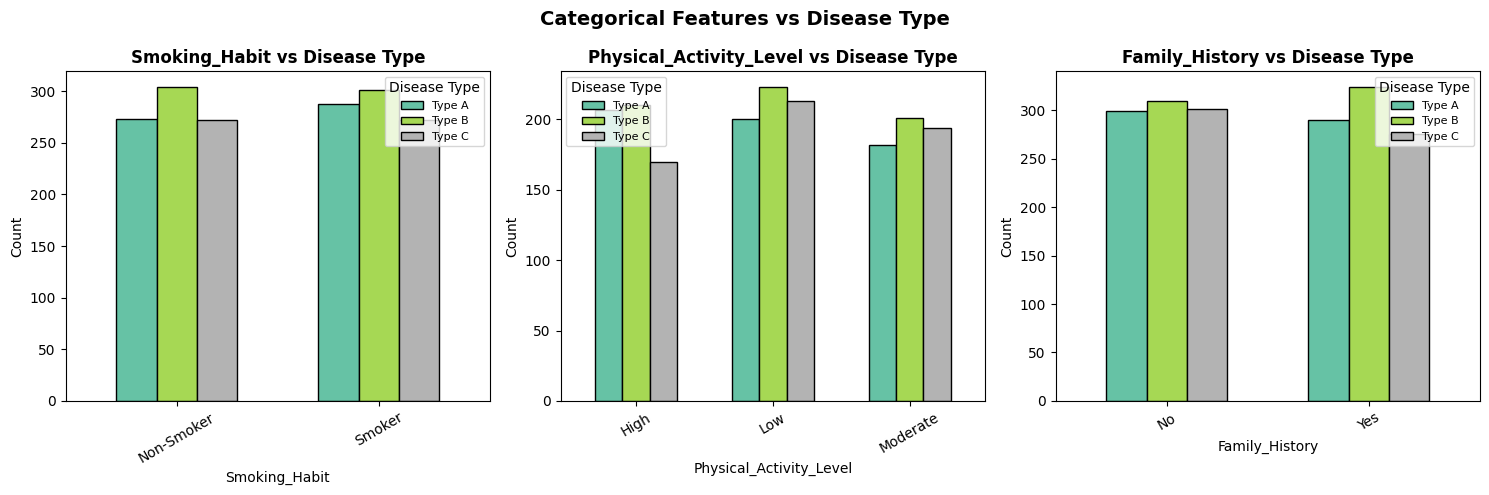

Observation: Each category value shows similar proportions
across disease types → categorical features also have weak predictive power.


In [34]:
# --- EDA Plot 2: Categorical features vs Disease Type ---
cat_cols = ['Smoking_Habit', 'Physical_Activity_Level', 'Family_History']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cat_cols):
    ct = df.groupby([col, 'Disease_Type']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.6)
    ax.set_title(f'{col} vs Disease Type', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Disease Type', fontsize=8)

plt.suptitle('Categorical Features vs Disease Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03b_eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Each category value shows similar proportions')
print('across disease types → categorical features also have weak predictive power.')

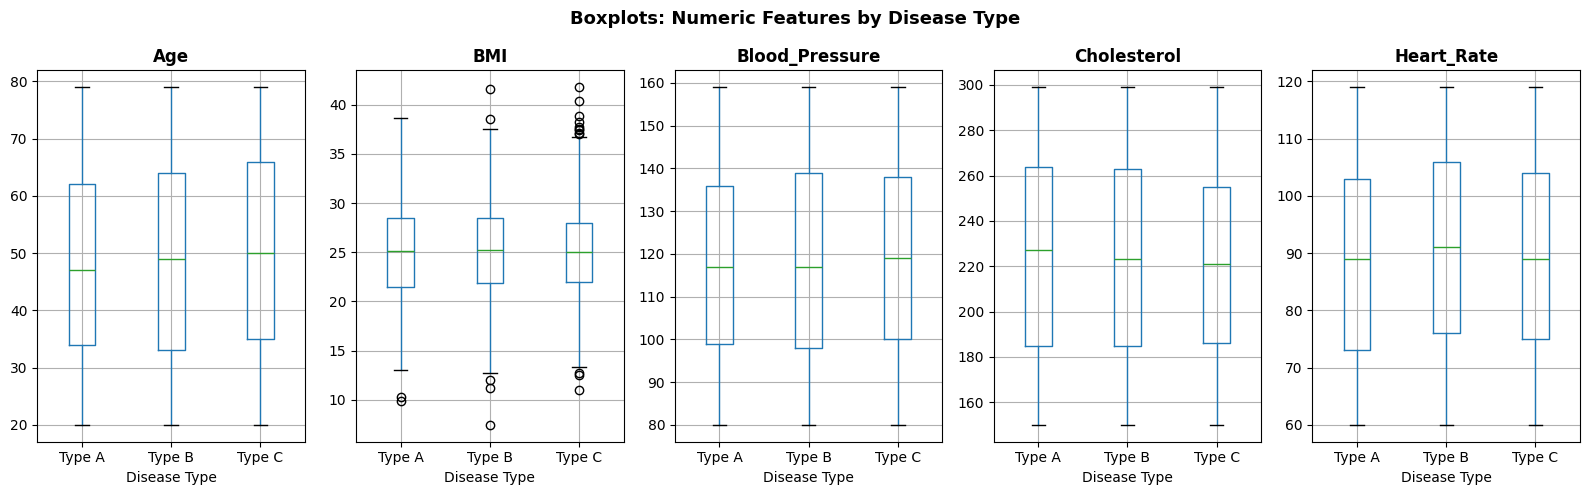

📌 Observation: Medians and IQRs are nearly identical across disease types.
Confirms no feature cleanly separates the classes.


In [35]:
# --- EDA Plot 3: Boxplots — outlier check ---
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='Disease_Type', ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Disease Type')
plt.suptitle('Boxplots: Numeric Features by Disease Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03c_eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Observation: Medians and IQRs are nearly identical across disease types.')
print('Confirms no feature cleanly separates the classes.')

---
## 🔧 Section 3: Dataset Pre-processing

### Fault 1: Null / Missing Values

In [36]:
print('Missing values BEFORE imputation:')
print(df.isnull().sum())
print()
print('BMI        : 90 missing (5.0% of data)')
print('Cholesterol: 90 missing (5.0% of data)')
print('Smoking_Habit: 90 missing (5.0% of data)')

Missing values BEFORE imputation:
Age                         0
BMI                        90
Blood_Pressure              0
Cholesterol                90
Heart_Rate                  0
Smoking_Habit              90
Physical_Activity_Level     0
Family_History              0
Disease_Type                0
dtype: int64

BMI        : 90 missing (5.0% of data)
Cholesterol: 90 missing (5.0% of data)
Smoking_Habit: 90 missing (5.0% of data)


**Solution — Imputation (not deletion):**
- Deleting 90 rows would remove 5% of our data and potentially bias class distribution.
- **BMI & Cholesterol** (continuous numeric) → imputed with **median** (robust to outliers).
- **Smoking_Habit** (categorical) → imputed with **mode** (most frequent value).

In [37]:
df_proc = df.copy()

# Calculate fill values from training data before split (safe here as exploratory step)
bmi_median   = df_proc['BMI'].median()
chol_median  = df_proc['Cholesterol'].median()
smoke_mode   = df_proc['Smoking_Habit'].dropna().mode()[0]

df_proc = df_proc.assign(
    BMI           = df_proc['BMI'].fillna(bmi_median),
    Cholesterol   = df_proc['Cholesterol'].fillna(chol_median),
    Smoking_Habit = df_proc['Smoking_Habit'].fillna(smoke_mode)
)

print(f'Imputed BMI          → median = {bmi_median:.2f}')
print(f'Imputed Cholesterol  → median = {chol_median:.2f}')
print(f'Imputed Smoking_Habit→ mode   = "{smoke_mode}"')
print()
print('Missing values AFTER imputation:')
print(df_proc.isnull().sum())

Imputed BMI          → median = 25.12
Imputed Cholesterol  → median = 223.50
Imputed Smoking_Habit→ mode   = "Smoker"

Missing values AFTER imputation:
Age                        0
BMI                        0
Blood_Pressure             0
Cholesterol                0
Heart_Rate                 0
Smoking_Habit              0
Physical_Activity_Level    0
Family_History             0
Disease_Type               0
dtype: int64


### Fault 2: Categorical Values

**Problem:** Smoking_Habit, Physical_Activity_Level, Family_History are text strings.
ML models need numeric inputs.

**Solution — Label Encoding:**
Converts each unique string label to an integer. Suitable for low-cardinality nominal features.

In [38]:
le = LabelEncoder()
cat_cols = ['Smoking_Habit', 'Physical_Activity_Level', 'Family_History']

for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col}: {mapping}')

# Encode target label
le_target = LabelEncoder()
df_proc['Disease_Type_enc'] = le_target.fit_transform(df_proc['Disease_Type'])
classes = le_target.classes_
print(f'\n  Disease_Type (target): {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')
print(f'  Classes: {classes}')

  Smoking_Habit: {'Non-Smoker': np.int64(0), 'Smoker': np.int64(1)}
  Physical_Activity_Level: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}
  Family_History: {'No': np.int64(0), 'Yes': np.int64(1)}

  Disease_Type (target): {'Type A': np.int64(0), 'Type B': np.int64(1), 'Type C': np.int64(2)}
  Classes: ['Type A' 'Type B' 'Type C']


### Fault 3: Feature Scaling

**Problem:** Features have very different ranges — e.g. Age (20–79) vs Cholesterol (150–299).
Distance-based (KNN) and gradient-based (Neural Network) models are sensitive to scale.

**Solution — StandardScaler (Z-score normalization):**
Transforms each feature to have mean=0, std=1.
⚠️ Fit on **training set only**, then apply to both train and test — prevents data leakage.

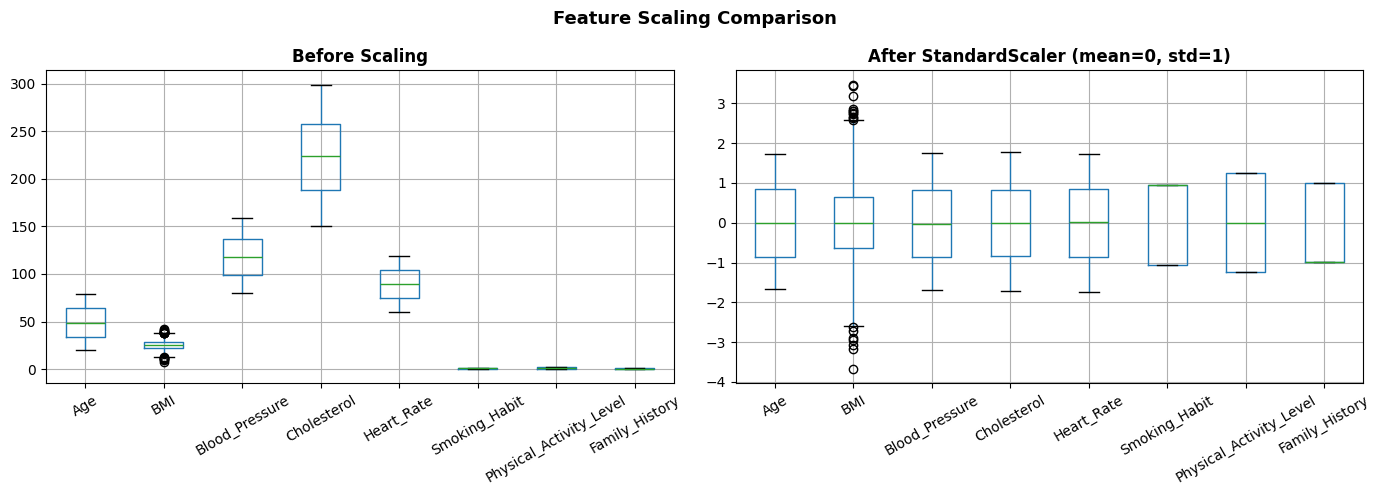

StandardScaler applied. All features now on the same scale.


In [39]:
X = df_proc.drop(['Disease_Type', 'Disease_Type_enc'], axis=1)
y = df_proc['Disease_Type_enc']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
X.boxplot(ax=ax1, rot=30)
ax1.set_title('Before Scaling', fontweight='bold')

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.boxplot(ax=ax2, rot=30)
ax2.set_title('After StandardScaler (mean=0, std=1)', fontweight='bold')

plt.suptitle('Feature Scaling Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print('StandardScaler applied. All features now on the same scale.')

---
## ✂️ Section 4: Dataset Splitting

**Type used: Stratified Split**

Why stratified? With 3 classes, a random split could by chance place very few instances
of one class in the test set. Stratified splitting ensures each class appears in the
**same proportion** in both train and test sets as in the full dataset.

- **Train set: 80% (1440 records)**
- **Test set: 20% (360 records)**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y        # ← stratified
)

print(f'Train size : {X_train.shape[0]} rows ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test  size : {X_test.shape[0]}  rows  ({X_test.shape[0]/len(y)*100:.0f}%)')
print(f'\nTrain class distribution: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'Test  class distribution: {dict(pd.Series(y_test).value_counts().sort_index())}')
print('\n Proportions maintained in both sets.')

Train size : 1440 rows (80%)
Test  size : 360  rows  (20%)

Train class distribution: {0: np.int64(471), 1: np.int64(507), 2: np.int64(462)}
Test  class distribution: {0: np.int64(118), 1: np.int64(127), 2: np.int64(115)}

 Proportions maintained in both sets.


---
## 🤖 Section 5: Model Training & Testing

> **As per guidelines:** Neural Network (mandatory) + at least 2 other models.
> We use: **Neural Network + Decision Tree + KNN**
> KMeans is applied separately as the unsupervised task.

### Model 1 — Decision Tree

In [41]:
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

print('Decision Tree Training complete.')
print(f'  max_depth = 8  (limits overfitting)')
print(f'  Train accuracy: {accuracy_score(y_train, dt_model.predict(X_train)):.4f}')
print(f'  Test  accuracy: {accuracy_score(y_test,  dt_pred):.4f}')

Decision Tree Training complete.
  max_depth = 8  (limits overfitting)
  Train accuracy: 0.5924
  Test  accuracy: 0.3472


### Model 2 — K-Nearest Neighbors (KNN)

In [42]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)

print('KNN Training complete.')
print(f'  k = 7 neighbours')
print(f'  Train accuracy: {accuracy_score(y_train, knn_model.predict(X_train)):.4f}')
print(f'  Test  accuracy: {accuracy_score(y_test,  knn_pred):.4f}')

KNN Training complete.
  k = 7 neighbours
  Train accuracy: 0.5194
  Test  accuracy: 0.3083


### Model 3 — Neural Network (MLP)

**Architecture:** Input(8) → Dense(128, ReLU) → Dense(64, ReLU) → Output(3, Softmax)

- Optimizer: Adam
- Early stopping: enabled (monitors validation loss, patience built-in)
- Framework: scikit-learn MLPClassifier

Neural Network Training complete.
  Hidden layers : (128, 64) neurons
  Iterations ran: 20
  Train accuracy: 0.3979
  Test  accuracy: 0.3361


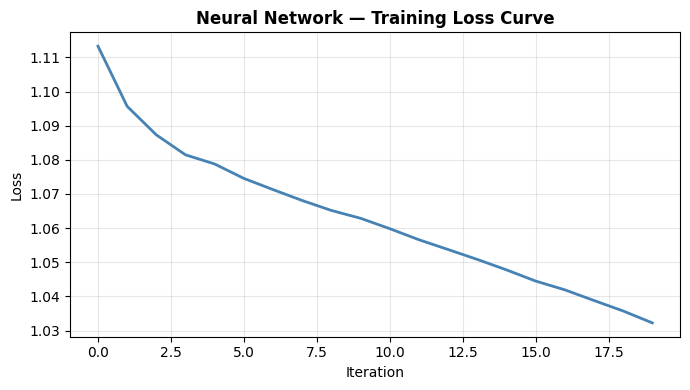

In [43]:
nn_model = MLPClassifier(
    hidden_layer_sizes = (128, 64),
    activation         = 'relu',
    solver             = 'adam',
    max_iter           = 500,
    random_state       = 42,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 15
)
nn_model.fit(X_train, y_train)

nn_pred = nn_model.predict(X_test)
nn_prob = nn_model.predict_proba(X_test)

print('Neural Network Training complete.')
print(f'  Hidden layers : (128, 64) neurons')
print(f'  Iterations ran: {nn_model.n_iter_}')
print(f'  Train accuracy: {accuracy_score(y_train, nn_model.predict(X_train)):.4f}')
print(f'  Test  accuracy: {accuracy_score(y_test,  nn_pred):.4f}')

# Plot training loss curve
plt.figure(figsize=(7, 4))
plt.plot(nn_model.loss_curve_, color='steelblue', linewidth=2)
plt.title('Neural Network — Training Loss Curve', fontweight='bold')
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('nn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Unsupervised Task — K-Means Clustering

> *Treat the problem as unsupervised: ignore labels, find natural clusters.*

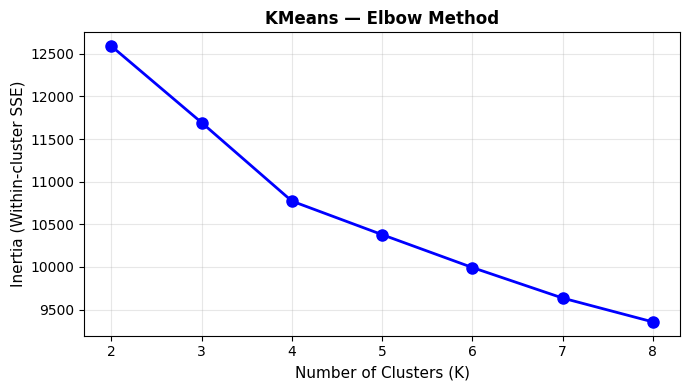

📌 Look for the "elbow" bend — that K minimises inertia without overfitting.
   No sharp elbow is visible here, consistent with low feature-target correlation.


In [44]:
inertias = []
K_range  = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Inertia (Within-cluster SSE)', fontsize=11)
plt.title('KMeans — Elbow Method', fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('05a_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Look for the "elbow" bend — that K minimises inertia without overfitting.')
print('   No sharp elbow is visible here, consistent with low feature-target correlation.')

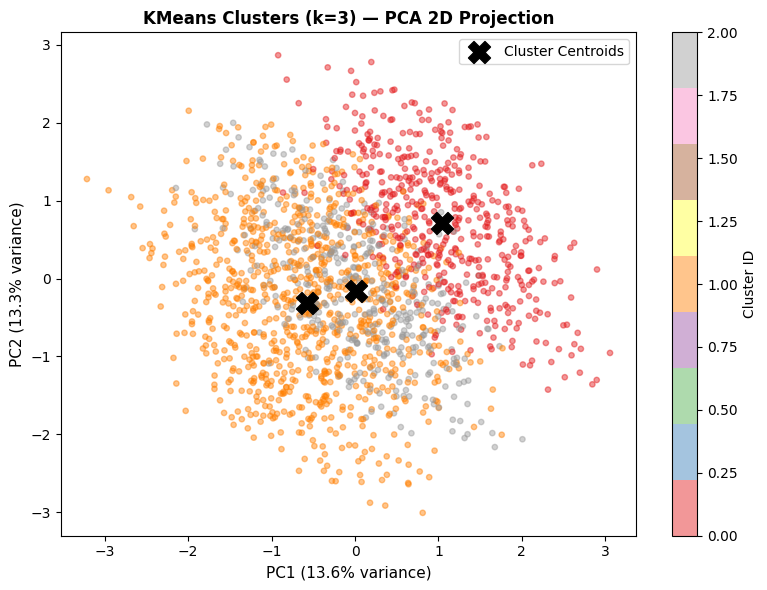

Total variance explained by 2 PCs: 26.9%
📌 Heavy cluster overlap confirms features do not form distinct natural groups.


In [45]:
kmeans         = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

pca    = PCA(n_components=2, random_state=42)
X_2d   = pca.fit_transform(X_scaled)
c_2d   = pca.transform(kmeans.cluster_centers_)

explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=cluster_labels, cmap='Set1',
                      alpha=0.45, s=15)
plt.scatter(c_2d[:, 0], c_2d[:, 1],
            c='black', marker='X', s=250,
            zorder=5, label='Cluster Centroids')
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.title('KMeans Clusters (k=3) — PCA 2D Projection', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('05b_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {sum(explained):.1f}%')
print('📌 Heavy cluster overlap confirms features do not form distinct natural groups.')

---
## 📈 Section 6: Model Comparison & Evaluation

### 6.1 Compute All Metrics

In [46]:
model_names = ['Decision Tree', 'KNN', 'Neural Network']
preds       = [dt_pred,  knn_pred,  nn_pred]
probs       = [dt_prob,  knn_prob,  nn_prob]

y_bin = label_binarize(y_test, classes=[0, 1, 2])

results = {}
for name, pred, prob in zip(model_names, preds, probs):
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, pred)
    auc  = roc_auc_score(y_bin, prob, multi_class='ovr')
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'cm': cm,
                     'auc': auc, 'prob': prob}

print(f"{'Model':20s} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'AUC':>10}")
print('-' * 60)
for name, r in results.items():
    print(f"{name:20s} {r['acc']:>10.4f} {r['prec']:>10.4f} {r['rec']:>10.4f} {r['auc']:>10.4f}")

Model                  Accuracy  Precision     Recall        AUC
------------------------------------------------------------
Decision Tree            0.3472     0.3505     0.3472     0.4999
KNN                      0.3083     0.3067     0.3083     0.4948
Neural Network           0.3361     0.3458     0.3361     0.5072


### 6.2 Accuracy Bar Chart

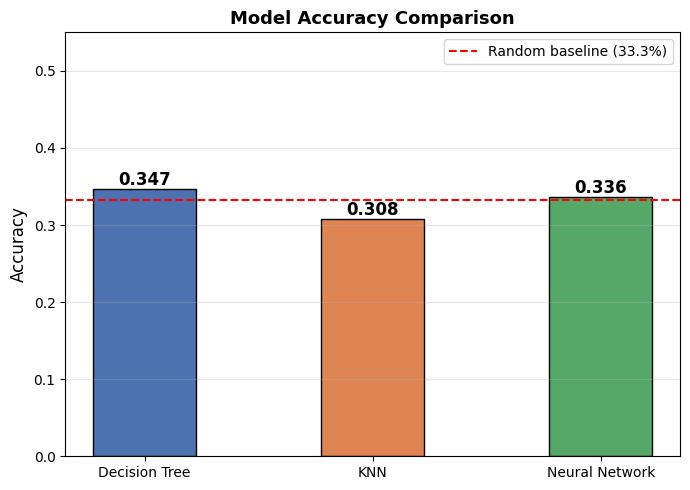

In [47]:
accs  = [results[m]['acc']  for m in model_names]

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, accs,
               color=['#4C72B0', '#DD8452', '#55A868'],
               edgecolor='black', width=0.45)
for bar, v in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.axhline(0.333, color='red', linestyle='--',
            linewidth=1.5, label='Random baseline (33.3%)')
plt.ylim(0, 0.55)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('06_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Precision & Recall Comparison

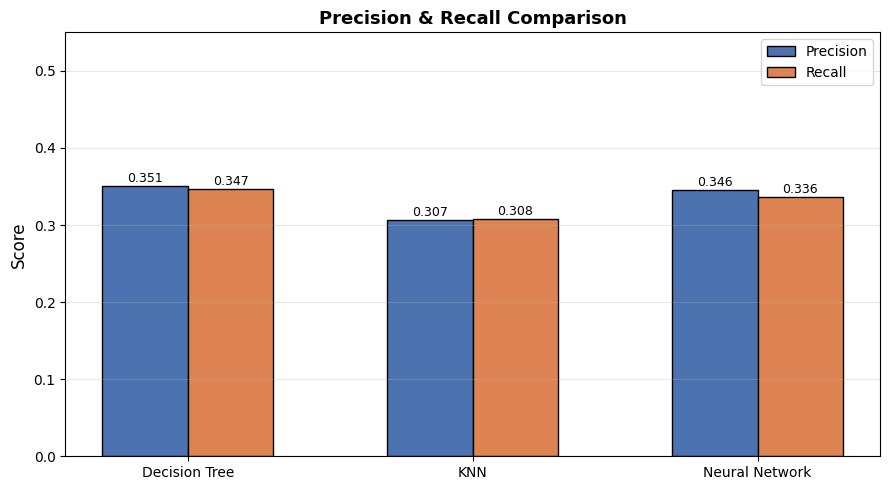

In [48]:
precs = [results[m]['prec'] for m in model_names]
recs  = [results[m]['rec']  for m in model_names]

x = np.arange(len(model_names)); w = 0.3
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, precs, w, label='Precision',
            color='#4C72B0', edgecolor='black')
b2 = ax.bar(x + w/2, recs,  w, label='Recall',
            color='#DD8452', edgecolor='black')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 0.55); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision & Recall Comparison', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('07_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Confusion Matrices

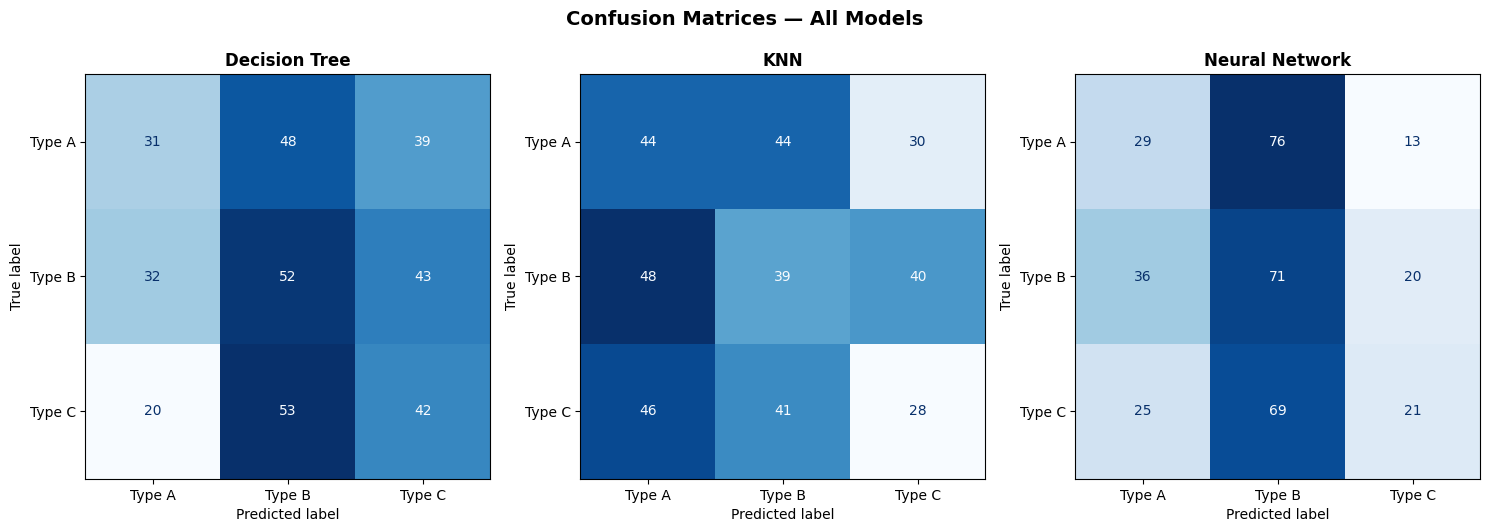

📌 All models spread predictions fairly uniformly across classes
   → consistent with near-zero feature-target correlation.


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, model_names):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=results[name]['cm'],
        display_labels=classes
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 All models spread predictions fairly uniformly across classes')
print('   → consistent with near-zero feature-target correlation.')

### 6.5 ROC Curves & AUC Scores

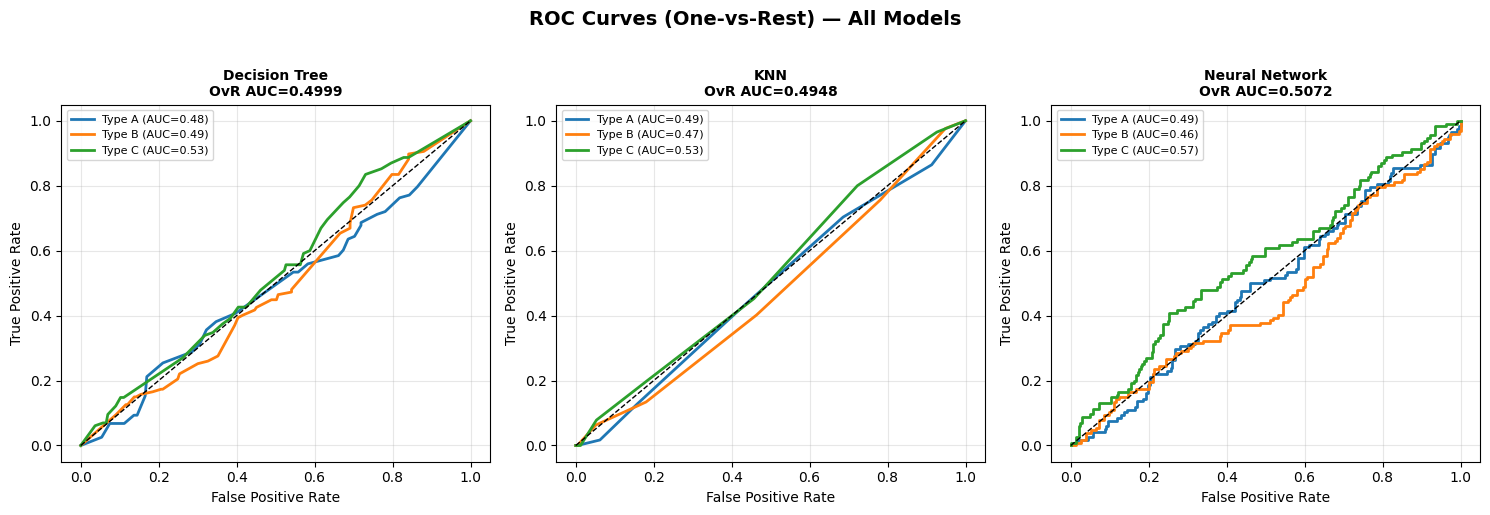

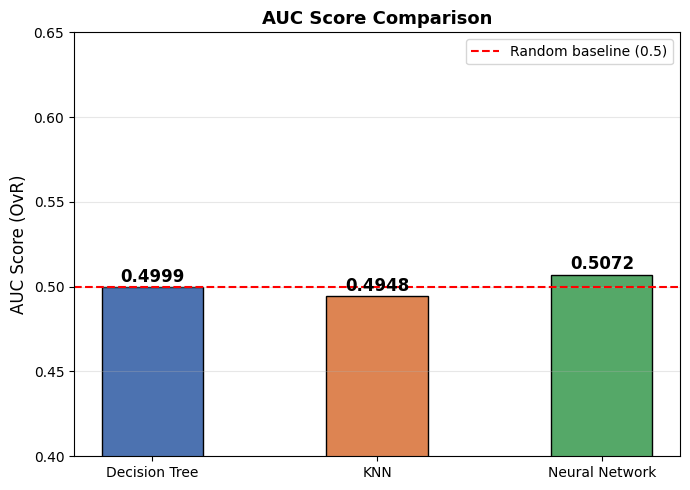

In [50]:
colors_list = ['#4C72B0', '#DD8452', '#55A868']
fig, axes   = plt.subplots(1, 3, figsize=(15, 5))

for ax, name, col in zip(axes, model_names, colors_list):
    prob = results[name]['prob']
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        auc_i = roc_auc_score(y_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, linewidth=2,
                label=f'{cls} (AUC={auc_i:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'{name}\nOvR AUC={results[name]["auc"]:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves (One-vs-Rest) — All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# AUC bar chart
aucs = [results[m]['auc'] for m in model_names]
plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, aucs,
               color=['#4C72B0','#DD8452','#55A868'],
               edgecolor='black', width=0.45)
for bar, v in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.axhline(0.5, color='red', linestyle='--',
            linewidth=1.5, label='Random baseline (0.5)')
plt.ylim(0.4, 0.65)
plt.ylabel('AUC Score (OvR)', fontsize=12)
plt.title('AUC Score Comparison', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('10_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Feature Importances (Decision Tree)

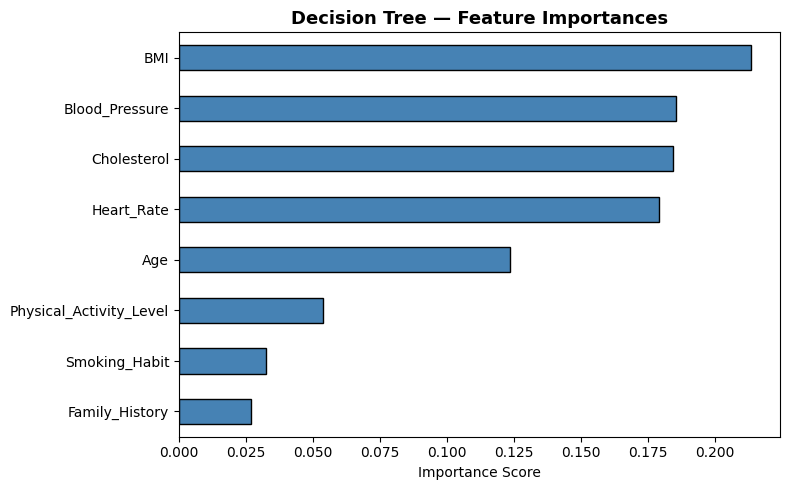

📌 No dominant feature exists — importances are nearly uniform.
   This further confirms the weak predictive signal in this dataset.


In [51]:
importances = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Decision Tree — Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 No dominant feature exists — importances are nearly uniform.')
print('   This further confirms the weak predictive signal in this dataset.')

### 6.7 Full Comparison Summary

In [52]:
import pandas as pd
summary = pd.DataFrame({
    'Model'    : model_names,
    'Accuracy' : [f"{results[m]['acc']:.4f}"  for m in model_names],
    'Precision': [f"{results[m]['prec']:.4f}" for m in model_names],
    'Recall'   : [f"{results[m]['rec']:.4f}"  for m in model_names],
    'AUC (OvR)': [f"{results[m]['auc']:.4f}"  for m in model_names],
})
print(summary.to_string(index=False))

best = model_names[np.argmax([results[m]['acc'] for m in model_names])]
print(f'\n🏆 Best model by accuracy: {best}')

         Model Accuracy Precision Recall AUC (OvR)
 Decision Tree   0.3472    0.3505 0.3472    0.4999
           KNN   0.3083    0.3067 0.3083    0.4948
Neural Network   0.3361    0.3458 0.3361    0.5072

🏆 Best model by accuracy: Decision Tree
